In [130]:
#importing important libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [77]:
#loading the dataset
df = pd.read_csv('C:\\Users\\Harsh gautam\\Downloads\\carmpg_2.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504.0,NaN,70,1,"""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,"""buick skylark 320"""
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,"""plymouth satellite"""
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,"""amc rebel sst"""
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,"""ford torino"""


In [78]:
#checking the dimesnsions
print("Shape of dataset:", df.shape)

Shape of dataset: (398, 9)


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 1 to 397
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mpg              354 non-null    float64
 1   cylinders        354 non-null    int64  
 2   displacement     354 non-null    float64
 3   horsepower       354 non-null    float64
 4   weight           354 non-null    float64
 5   acceleration     354 non-null    float64
 6   model year       354 non-null    int64  
 7   origin           354 non-null    int64  
 8   car name         354 non-null    object 
 9   power_to_weight  354 non-null    float64
 10  car_age          354 non-null    int64  
dtypes: float64(6), int64(4), object(1)
memory usage: 33.2+ KB


In [81]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,388.000000,383.000000,388.000000,388.000000,398.000000,398.000000
mean,23.514573,5.454774,194.255155,104.216710,2956.056701,15.536082,76.010050,1.572864
std,7.815984,1.701004,104.825975,38.258251,843.805210,2.708564,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,103.250000,75.000000,2220.000000,13.875000,73.000000,1.000000
50%,23.000000,4.000000,151.000000,93.000000,2789.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,125.000000,3564.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [82]:
df.isnull().sum()

mpg              0
cylinders        0
displacement    10
horsepower      15
weight          10
acceleration    10
model year       0
origin           0
car name         0
dtype: int64

In [83]:
#data cleaning
df["horsepower"] = pd.to_numeric(df["horsepower"])

In [84]:
print(df.isnull().sum())

mpg              0
cylinders        0
displacement    10
horsepower      15
weight          10
acceleration    10
model year       0
origin           0
car name         0
dtype: int64


In [85]:
#removing rows containing missng values
df = df.dropna()

In [86]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (354, 9)


## EDA-Eploratory Data Analysis 

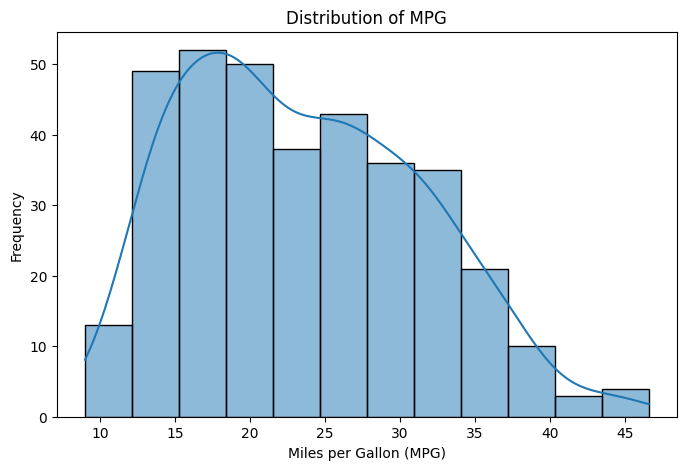

In [87]:
#1 distribution of MPG
plt.figure(figsize=(8, 5))

sns.histplot(
    df["mpg"],
    kde=True
)

plt.title("Distribution of MPG")
plt.xlabel("Miles per Gallon (MPG)")
plt.ylabel("Frequency")

plt.show()

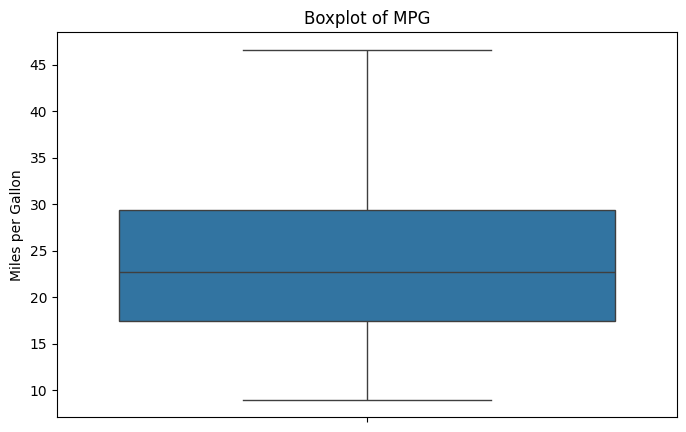

In [127]:
#BoxPLot of MPG
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=df["mpg"]
)

plt.title("Boxplot of MPG")
plt.ylabel("Miles per Gallon")

plt.show()

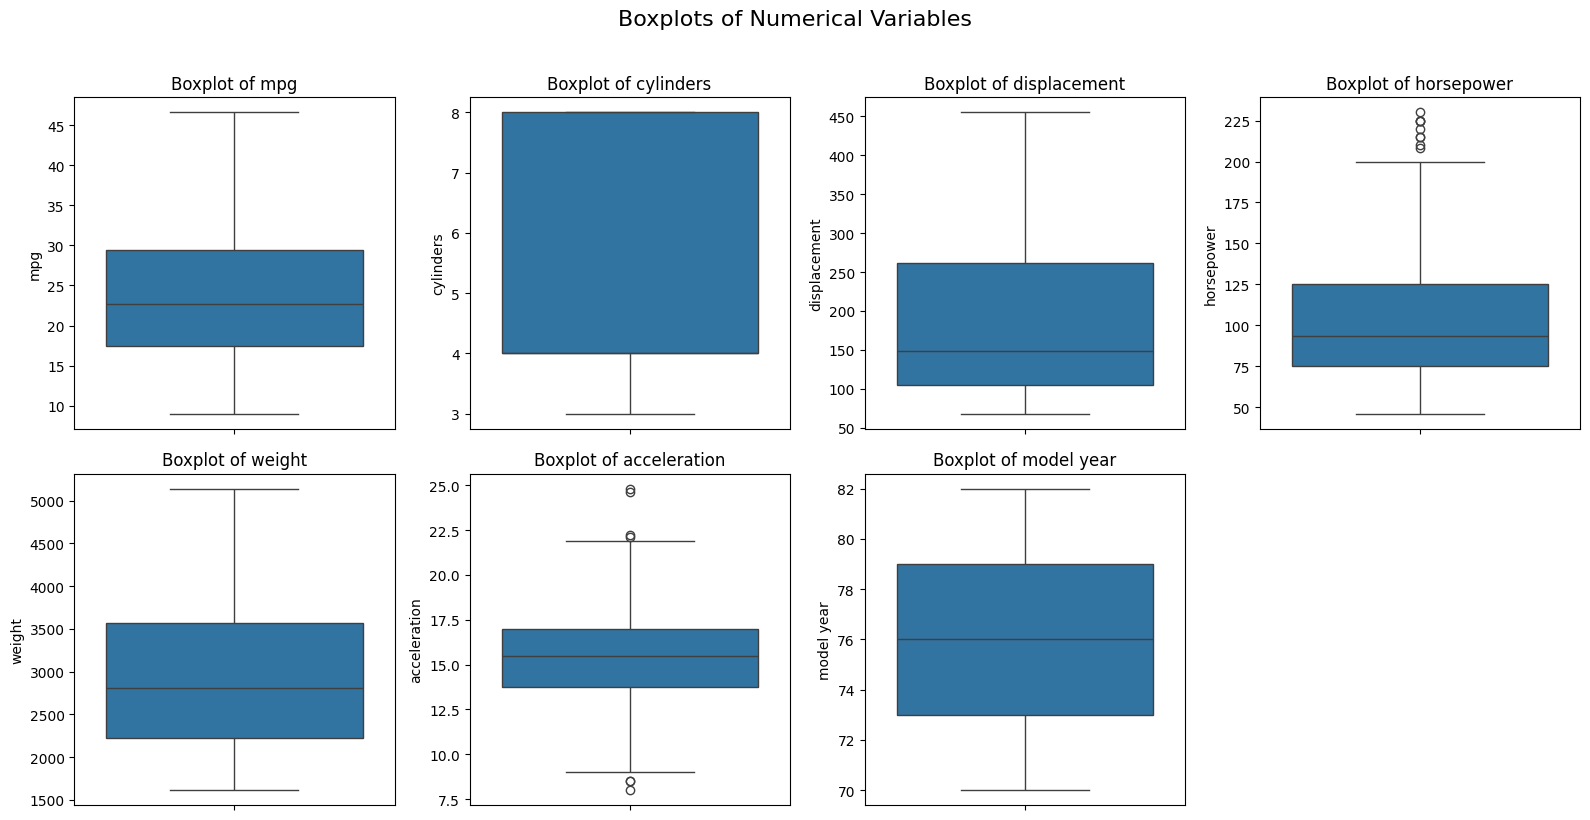

In [89]:
#Boxplots for Numerical Variables
numeric_cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model year"
]

fig, axes = plt.subplots(
    2, 4,
    figsize=(16, 8)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)
    axes[i].set_xlabel("")

# Hide the unused 8th subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Boxplots of Numerical Variables",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

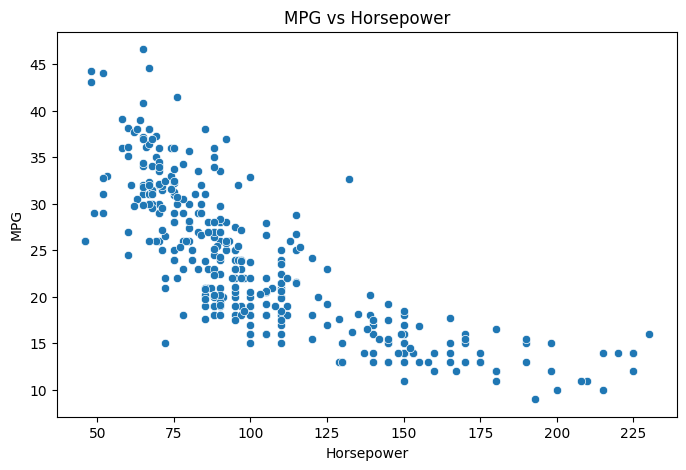

In [90]:
#mpg vs horsepower
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="horsepower",
    y="mpg"
)

plt.title("MPG vs Horsepower")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

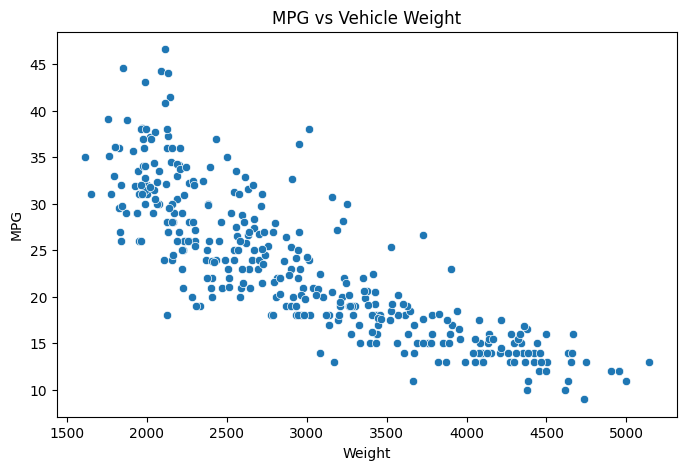

In [91]:
#mpg vs weight
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("MPG vs Vehicle Weight")
plt.xlabel("Weight")
plt.ylabel("MPG")

plt.show()

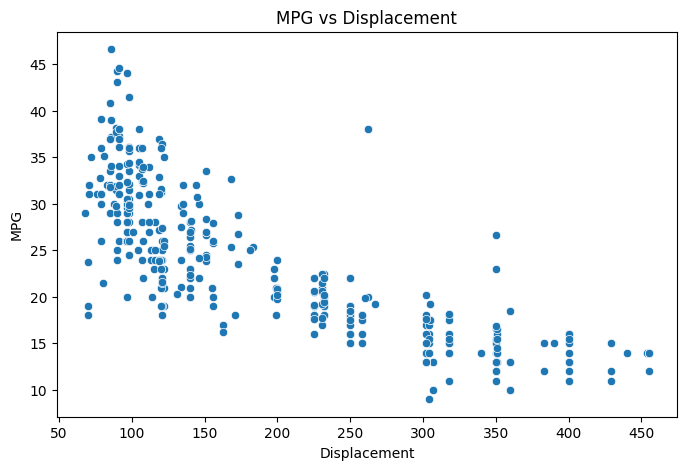

In [92]:
#mpg vs displacement
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="displacement",
    y="mpg"
)

plt.title("MPG vs Displacement")
plt.xlabel("Displacement")
plt.ylabel("MPG")

plt.show()

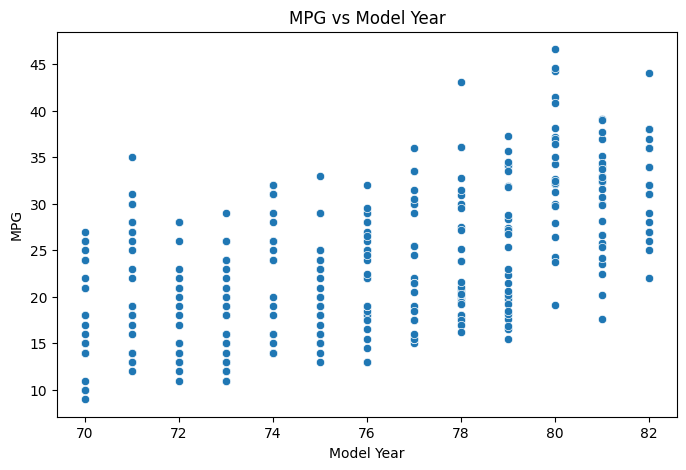

In [93]:
#mpg vs model year
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="model year",
    y="mpg"
)

plt.title("MPG vs Model Year")
plt.xlabel("Model Year")
plt.ylabel("MPG")

plt.show()

## FEATURE ENGINEERING

In [94]:
#power to weight
df["power_to_weight"] = df["horsepower"] / df["weight"]

In [95]:
#car age
df["car_age"] = 2026 - df["model year"]

In [96]:
df[[
    "horsepower",
    "weight",
    "power_to_weight",
    "model year",
    "car_age"
]].head()

,horsepower,weight,power_to_weight,model year,car_age
1,165.0,3693.0,0.044679,70,1956
2,150.0,3436.0,0.043655,70,1956
3,150.0,3433.0,0.043694,70,1956
4,140.0,3449.0,0.040591,70,1956
5,198.0,4341.0,0.045612,70,1956


## EDA after feature engineering

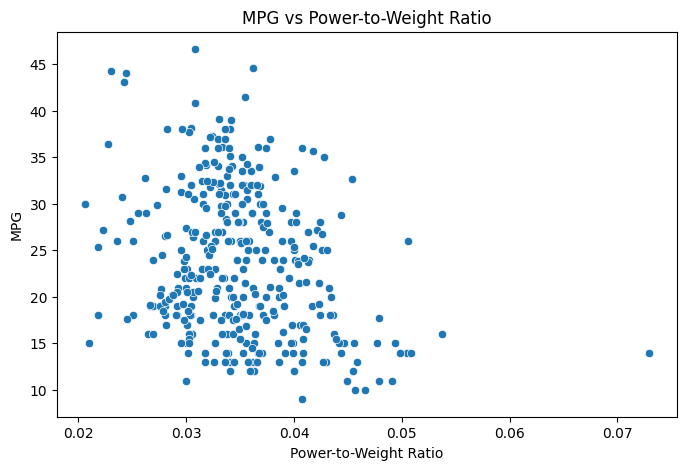

In [97]:
#MPG vs Power-to-Weight
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="power_to_weight",
    y="mpg"
)

plt.title("MPG vs Power-to-Weight Ratio")
plt.xlabel("Power-to-Weight Ratio")
plt.ylabel("MPG")

plt.show()

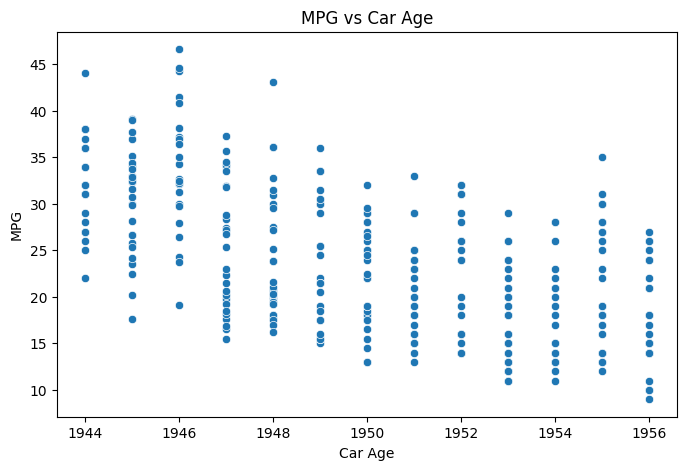

In [98]:
#MPG vs Car Age
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="car_age",
    y="mpg"
)

plt.title("MPG vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("MPG")

plt.show()

## CORRELATION HEATMAP

In [99]:
corr_cols = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model year",
    "power_to_weight",
    "car_age"
]

corr_matrix = df[corr_cols].corr()

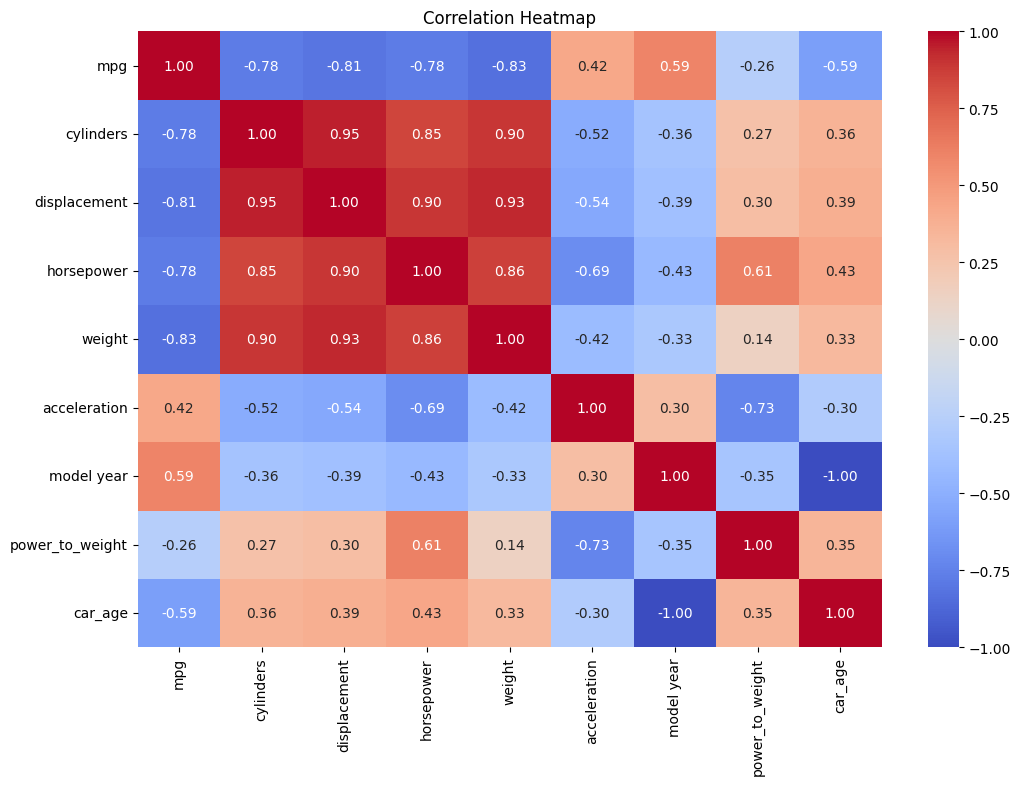

In [100]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

## DEFINING FEATURES AND TARGET

In [101]:
y = df["mpg"]

features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "origin",
    "power_to_weight",
    "car_age"
]

X = df[features]

## TRAIN - TEST SPLIT

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (283, 8)
Testing set: (71, 8)


## FEATURE SCALING

In [103]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test) 

## MULTIPLE LINEAR REGRESSION

In [104]:
# MODEL
mlr = LinearRegression()

mlr.fit(
    X_train_scaled,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [105]:
y_pred_mlr = mlr.predict(X_test_scaled)

## RIDGE REGRESSION

In [106]:
ridge = Ridge(alpha=1.0)

ridge.fit(
    X_train_scaled,
    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [107]:
y_pred_ridge = ridge.predict(X_test_scaled)

## LASSO REGRESSION 

In [108]:
lasso = Lasso(alpha=0.1)

lasso.fit(
    X_train_scaled,
    y_train
)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [109]:
y_pred_lasso = lasso.predict(X_test_scaled)

In [131]:
## model evaluation
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2 Score": r2
    }

## COMPARE ALL THREE MODELS

In [112]:
results = []

results.append(
    evaluate_model(
        "Multiple Linear Regression",
        y_test,
        y_pred_mlr
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        y_pred_ridge
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        y_pred_lasso
    )
)

results_df = pd.DataFrame(results)

print(results_df)

                        Model       MAE        MSE  R2 Score
0  Multiple Linear Regression  2.420189  10.586065  0.829913
1            Ridge Regression  2.436797  10.533053  0.830765
2            Lasso Regression  2.463211  11.073661  0.822079


In [116]:
#Feature Importance / Regression Coefficients
coefficients = pd.DataFrame({
    "Feature": features,
    "MLR": mlr.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_
})

print(coefficients)

           Feature        MLR     Ridge     Lasso
0        cylinders  -0.368607 -0.501557 -0.000000
1     displacement   0.631639  0.798334 -0.000000
2       horsepower   7.311501  4.140831 -0.000000
3           weight -11.096597 -8.549227 -4.990579
4     acceleration  -0.209485 -0.132318  0.000000
5           origin   1.087681  1.103752  0.931541
6  power_to_weight  -4.364877 -2.748523 -0.463959
7          car_age  -2.659251 -2.665185 -2.606957


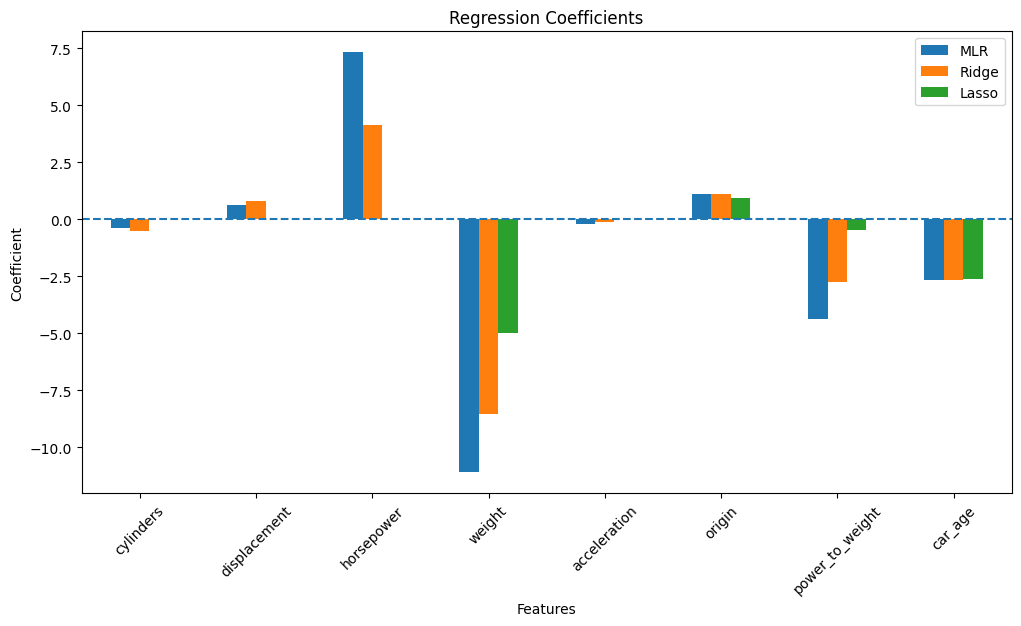

In [117]:
#plotting regression coefficients
coefficients.set_index("Feature").plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.axhline(0, linestyle="--")

plt.xticks(rotation=45)

plt.show()

## Prediction for a New Car

In [120]:
new_car = pd.DataFrame({
    "cylinders": [4],
    "displacement": [120],
    "horsepower": [90],
    "weight": [2200],
    "acceleration": [16],
    "origin": [3],
    "power_to_weight": [90 / 2200],
    "car_age": [2026 - 1980]
})

In [121]:
new_car_scaled = scaler.transform(new_car)

In [122]:
mlr_prediction = mlr.predict(new_car_scaled)

ridge_prediction = ridge.predict(new_car_scaled)

lasso_prediction = lasso.predict(new_car_scaled)

In [123]:
print("MLR predicted MPG:", mlr_prediction[0])
print("Ridge predicted MPG:", ridge_prediction[0])
print("Lasso predicted MPG:", lasso_prediction[0])

MLR predicted MPG: 1414.2027412892737
Ridge predicted MPG: 1417.8320225401924
Lasso predicted MPG: 1387.941677619547
